Lutas REALIZADO: 1597 | Período: 2003-2026
Decisivas: 1575 | Title fights: 143

[Q1] Spearman (year vs duration, non-title): rho=0.033, p=0.2126, n=1409

[Q2] Qui-quadrado pre/post-2020: chi2=3.42, p=0.3315, V de Cramer=0.047, n=1575

[Q3] Classes analisadas: 10
                      n    mean   std  median
weight_class_clean                           
Heavyweight          49  187.18  6.58  187.96
Light Heavyweight    48  183.36  5.54  185.42
Middleweight        163  183.22  5.25  182.88
Welterweight        308  180.69  5.27  180.34
Lightweight         334  176.78  5.31  177.80
Catchweight          57  173.97  7.30  172.72
Featherweight       425  173.92  5.34  175.26
Bantamweight        487  170.10  5.55  170.18
Flyweight           363  166.69  4.79  167.64
Strawweight          37  161.19  4.66  162.56

[Q4] Resultados por classe:
        group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
 Welterweight 120    0.5667  0.4773   0.6519   0.1706      0.2872        Fals

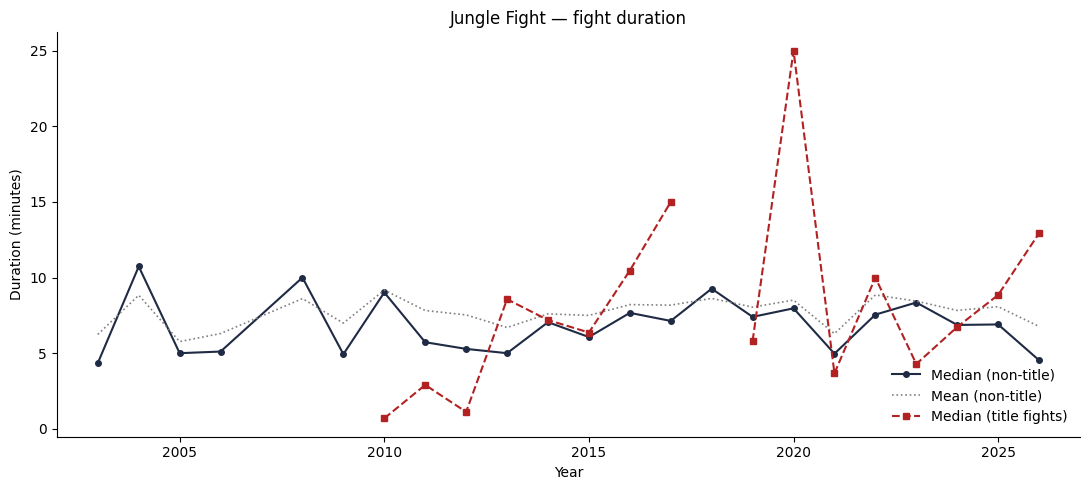

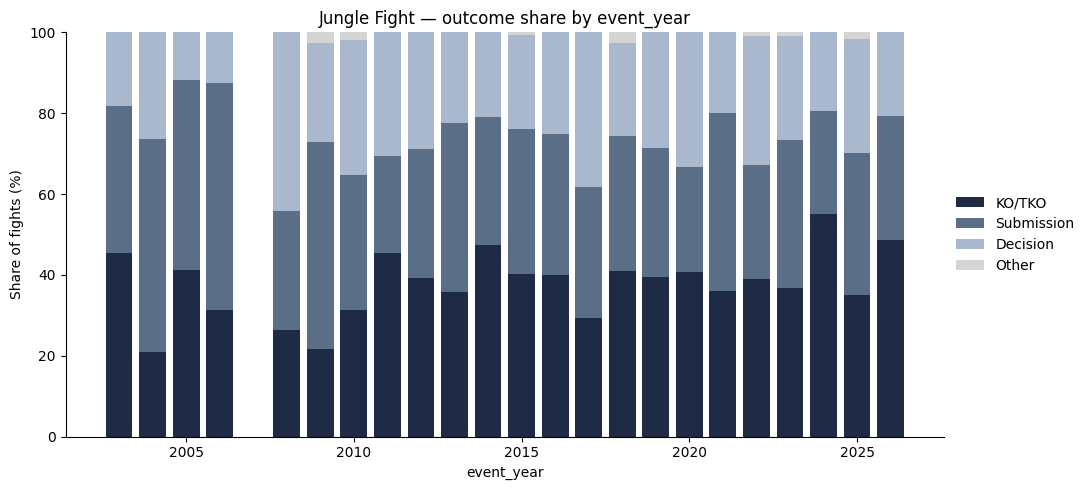

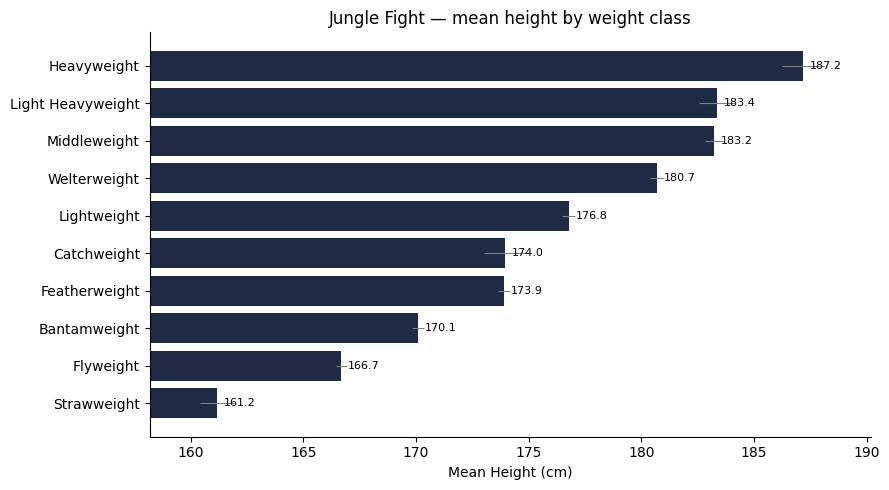

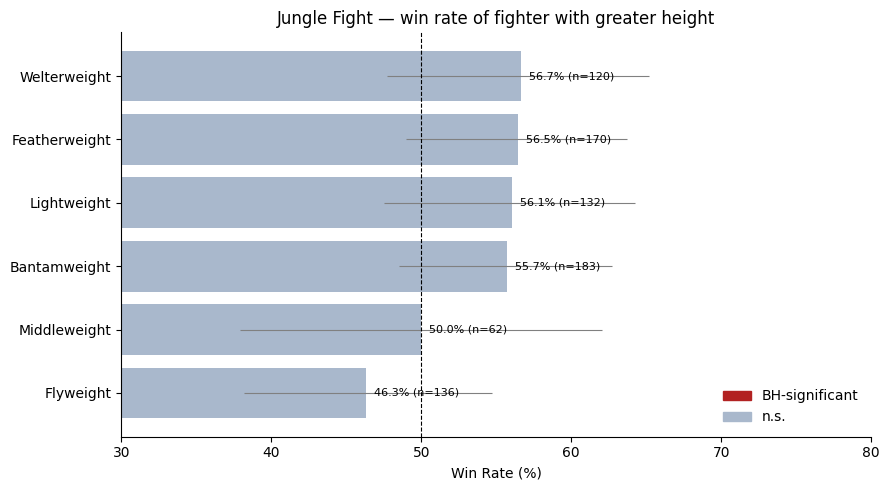

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/jungle-fight-complete-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_jungle_fight.csv'
JSON_PATH = f'{DATA_DIR}/jungle_fight_win_title_data.json'


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_jungle_fight():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True, errors='coerce')
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            return (int(row['round_num']) - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color='#1f2a44',
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color='#b22222',
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('Jungle Fight — fight duration')
    ax.legend(loc='lower right', frameon=False)
    ax.set_xlim(df['event_year'].min() - 1, df['event_year'].max() + 1)
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2020):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {'KO/TKO': '#1f2a44', 'Submission': '#5b6e88',
               'Decision': '#a9b8cc', 'Other': '#d4d4d4'}
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat, color=palette[cat])
        bottom += props[cat].values
    ax.set_xlabel('event_year')
    ax.set_ylabel('Share of fights (%)')
    ax.set_title('Jungle Fight — outcome share by event_year')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_ylim(0, 100)
    sns.despine()
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    desc_sorted = desc.sort_values('mean')
    ax.barh(desc_sorted.index, desc_sorted['mean'], color='#1f2a44',
            xerr=desc_sorted['std'] / np.sqrt(desc_sorted['n']),
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + 0.3, i, f"{row['mean']:.1f}",
                va='center', fontsize=8)
    ax.set_xlabel('Mean Height (cm)')
    ax.set_title('Jungle Fight — mean height by weight class')
    ax.set_xlim(desc_sorted['mean'].min() - 3, desc_sorted['mean'].max() + 3)
    sns.despine()
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    valid = res[~res['underpowered']].copy()
    valid = valid.sort_values('win_rate')
    colors = ['#b22222' if s else '#a9b8cc' for s in valid['significant']]
    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[(valid['win_rate'] - valid['ci_low']) * 100,
                  (valid['ci_high'] - valid['win_rate']) * 100],
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    ax.axvline(50, ls='--', color='black', linewidth=0.8)
    for i, (_, row) in enumerate(valid.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.5, i,
                f"{row['win_rate']*100:.1f}% (n={row['n']})",
                va='center', fontsize=8)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('Jungle Fight — win rate of fighter with greater height')
    ax.set_xlim(30, 80)
    handles = [plt.Rectangle((0, 0), 1, 1, color='#b22222'),
               plt.Rectangle((0, 0), 1, 1, color='#a9b8cc')]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right', frameon=False)
    sns.despine()
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_jungle_fight()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_jungle_duration.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2020)
    fig2.savefig('q2_jungle_outcomes.png', dpi=120, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2020: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_jungle_height.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_jungle_height_winrate.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time

What the chart does show is persistent volatility around a stable baseline. The non-title median oscillates between 5 and 10 minutes throughout the entire period, with the mean tracking just slightly above. This is structurally different from the modern UFC, where the median is pinned at the 15-minute regulation ceiling because most fights go to a decision. In Jungle Fight, finishes remain the dominant outcome, which keeps the median anchored well below the cap.

Title fights (red dashed line) display extreme year-to-year volatility, including an isolated peak at 25 minutes in 2020. This is a sample-size artifact: there are 143 title fights spread across 23 years, averaging fewer than 7 per year. A single bout going the full distance can move the annual median by 5 to 10 minutes. The series is too sparse to support any trend inference and should be read as a descriptive overlay, not as a comparable signal.

Operational gaps also matter for interpretation. Activity dropped sharply in 2017-2018 (34 and 40 fights) and again during the pandemic in 2020-2021 (27 and 26 fights), before recovering to 120+ fights per year from 2022 onward. These low-N years amplify the visual noise without reflecting any underlying change in fight dynamics.

## Q2 > Outcome Distribution Over Time
The outcome distribution at Jungle Fight is statistically stable. A chi-square test comparing pre-2020 and post-2020 regimes returns χ² = 3.42, p = 0.331, with a Cramér's V of 0.047. The null hypothesis of no association between period and outcome composition cannot be rejected, and the effect size is negligible.

What stands out is not the temporal stability but the composition itself compared to the modern UFC. Across the full Jungle Fight history, KO/TKO accounts for roughly 38% of decisive fights, submissions for 35%, and decisions for 25-30%. The UFC modern equilibrium (post-2010) is approximately 30-35% KO/TKO, 15-20% submissions, and 50% decisions.

Submissions occur at roughly twice the rate seen in the modern UFC, and decisions at roughly half. Two non-exclusive hypotheses are consistent with this pattern: a roster with a stronger grappling base, plausibly tied to the Brazilian regional ecosystem and its training infrastructure; and a card structure that includes elimination tournaments with 2-round fights (visible in the 2025-2026 events like "Grand Prix Quarterfinals"), which mechanically reduces the window for decisions and increases the relative weight of early finishes. Disentangling the two would require fight-level metadata that the current dataset does not capture.


## Q3 > Mean Height by Weight Class
The mean height progression mirrors the UFC's ordinal structure almost perfectly: heights scale monotonically from Strawweight to Heavyweight across both promotions. The absolute values, however, are uniformly lower at Jungle Fight, with each division averaging roughly 0.2 to 4.4 centimeters below its UFC counterpart.

The gap is widest at Heavyweight (187.2 vs 190.1 cm) and Light Heavyweight (183.4 vs 187.8 cm), where the Jungle Fight roster averages 3 to 4 cm shorter than the UFC. This is consistent with a regional promotion that does not yet attract the global tail of 195+ cm heavyweights now concentrated at the elite international tier. In the middle divisions (Middleweight, Welterweight, Lightweight), the gap shrinks to between 0.2 and 1.3 cm. By the lighter divisions (Featherweight downward), it stays under 1.1 cm, indicating that lower-weight athletes are physically interchangeable between the two promotions.

The Catchweight bucket (174.0 cm, n = 57) lands between Lightweight and Featherweight, which is internally consistent: catchweight bouts at Jungle Fight aggregate athletes from 127lb to 215lb, and the resulting mean reflects the weight-weighted central tendency of that mix. Strawweight at Jungle Fight (161.2 cm) appears to be predominantly a women's division based on the event metadata, matching the UFC women's Strawweight at 161.6 cm.

## Q4 > Win Rate by Height Advantage
The same null result observed in the UFC holds at Jungle Fight. Across the six weight classes with sufficient sample (n ≥ 30), the win rate of the taller fighter never reaches statistical significance after Benjamini-Hochberg correction.

Four classes cluster tightly between 55.7% and 56.5% in favor of the taller fighter: Featherweight (56.5%, n = 170), Welterweight (56.3%, n = 119), Lightweight (56.1%, n = 132), and Bantamweight (55.7%, n = 183). All four return identical BH-adjusted p-values of 0.299, with 95% Wilson confidence intervals that all cross the 50% baseline. Middleweight sits essentially at the null (50.8%, n = 61, p-adj = 1.000), and Flyweight is the only class with a point estimate below the baseline (46.3%, n = 136, p-adj = 0.529).

The directional pattern across four of the six classes is suggestive the taller fighter wins more often on average but no class survives multiple testing correction. The proper inferential conclusion is that the available evidence is insufficient to reject the null hypothesis of no height effect, which is not the same as concluding that no effect exists. With the current sample sizes per class (median n ≈ 134), the analysis is underpowered to detect effects smaller than approximately 8 to 10 percentage points away from 50%.

Flyweight being the only class with a point estimate below 50% aligns with the UFC pattern where the lightest divisions tend to favor shorter, more compact fighters. The interpretation parallels the UFC analysis: in isolation, height is not a reliable predictor of victory. Counter-advantages associated with shorter stature — lower center of gravity, leverage in clinch and grappling, faster inside boxing range appear to neutralize whatever distance management benefit additional height might offer.

Heavyweight, Light Heavyweight, Catchweight, and Strawweight were excluded from the test due to insufficient sample size (n < 30 with both fighters' heights recorded). Including them would require either relaxing the threshold and accepting very wide confidence intervals, or waiting for additional events to accumulate.